In [46]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

In [47]:
RUN_ID = '1305_hSOC'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(2e3)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [48]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)

data = data[data['soc']>0.3]
display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.009707,1785.063477,0.007000,0.032111,0.000000,0.000042
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.009707,1785.366211,0.007000,0.032111,0.000042,0.000042
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.009707,1785.670776,0.007000,0.032111,0.000084,0.000042
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.009707,1785.975342,0.007000,0.032112,0.000127,0.000042
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.009707,1786.280151,0.007000,0.032112,0.000169,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...
209511,124,5.00,0.0,24.891078,0.000000,0.306944,0.178915,7883.280762,0.007003,0.023241,0.262512,0.000538
209512,124,5.00,0.0,24.891078,0.000000,0.305556,0.181236,7831.600586,0.007004,0.023242,0.263050,0.000538
209513,124,5.00,0.0,24.891078,0.000000,0.304167,0.183142,7779.417480,0.007004,0.023243,0.263589,0.000538
209514,124,5.00,0.0,24.891078,0.000000,0.302778,0.184697,7726.738281,0.007005,0.023245,0.264127,0.000538


In [49]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [50]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


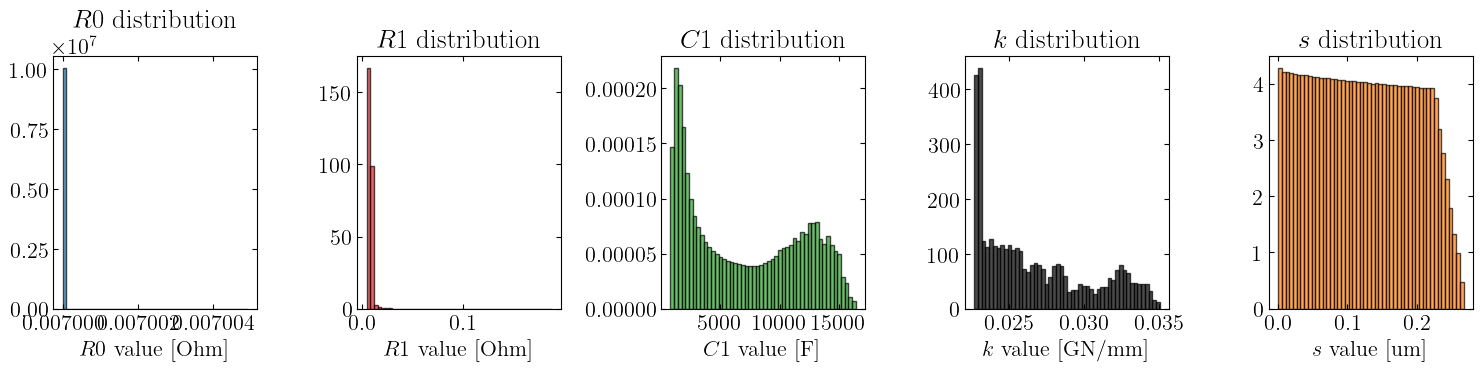

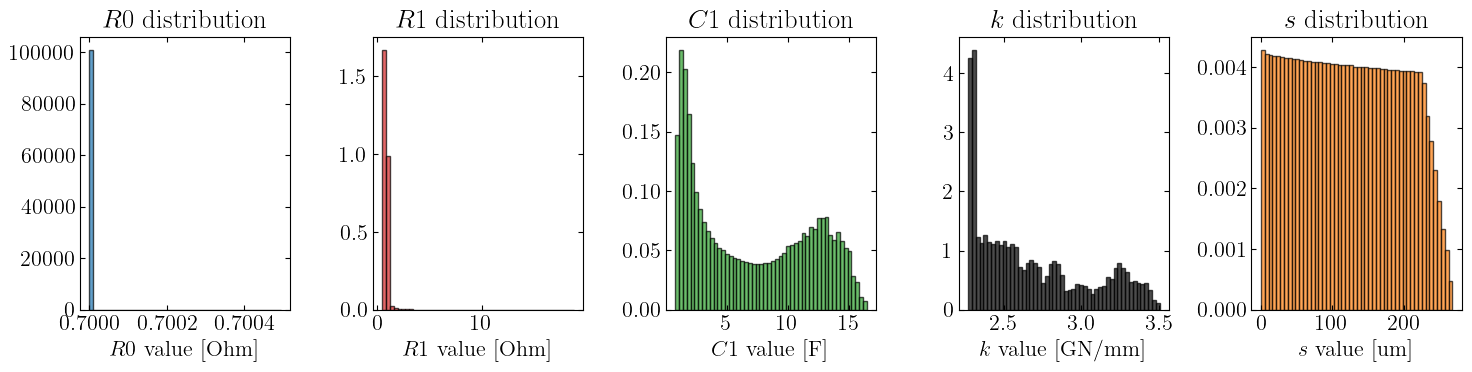

In [51]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [52]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [53]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 3th data point for symbolic regression, total points: 48983
Using every 1th data point for symbolic regression, total points: 13892


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=3.466186e-16
Equation: 0.70000005

Model 1: Complexity=11, Loss=3.1615619000000004e-16
Equation: 0.7 / (((x0 / x2) + 6.6051216) ^ -5.0757222e-8)

Model 2: Complexity=15, Loss=3.1608366000000003e-16
Equation: 0.7 / ((((x2 + (x0 + 0.35049134)) / x2) + x0) ^ -5.1360253e-8)

Model 3: Complexity=17, Loss=3.0941094e-16
Equation: 0.7 / (exp(exp((0.15581669 / x2) * x0)) ^ -2.7362661e-8)

Model 4: Complexity=19, Loss=2.7140548000000003e-16
Equation: 0.7 / (exp(exp(cube(x0 / x2) * 0.0010936115)) ^ -2.9813787e-8)

Model 5: Complexity=20, Loss=2.5588415e-16
Equation: 0.7 / (exp(exp(exp((x2 / -0.10081373) + x0))) ^ -2.9813787e-8)

Model 6: Complexity=22, Loss=1.997463e-16
Equation: 0.7 / (exp(exp(exp((x0 + (x2 / -0.117525436)) - x1))) ^ -2.9813787e-8)

Model 7: Complexity=24, Loss=1.1960118000000002e-16
Equation: 0.7 / (exp(exp(exp(((x2 / -0.10081373) + x0) / (x1 + 0.6875369)))) ^ -2.9813787e-8)

Model 8: Complexity=26, Loss=6.266551000000001e-17
Equation: 0.7 / (exp(exp

<lambdifygenerated-31>:2: RuntimeWarning: overflow encountered in exp
  return 0.7/exp(exp(exp((x0 - 0.021295063*x1 + x2/(-0.10081373))/0.6895431)))**(-2.9813787e-8)
<lambdifygenerated-31>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.7/exp(exp(exp((x0 - 0.021295063*x1 + x2/(-0.10081373))/0.6895431)))**(-2.9813787e-8)


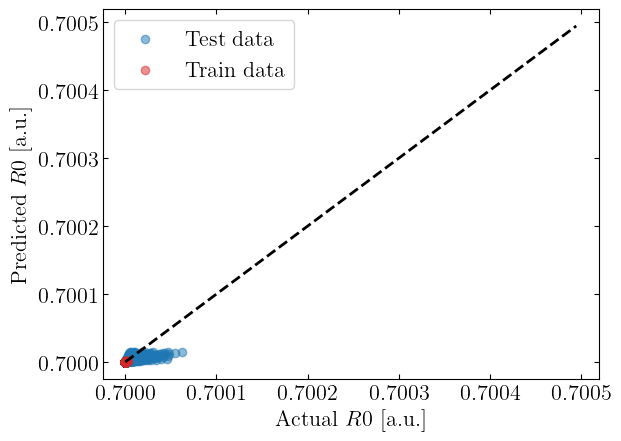

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.7/(exp(exp(exp((x0 - 0.021295063*x1 + x2/(-0.10081373))/0.6895431)))**(-2.9813787e-8))
Loss: 6.266551000000001e-17
Best model complexity: 26


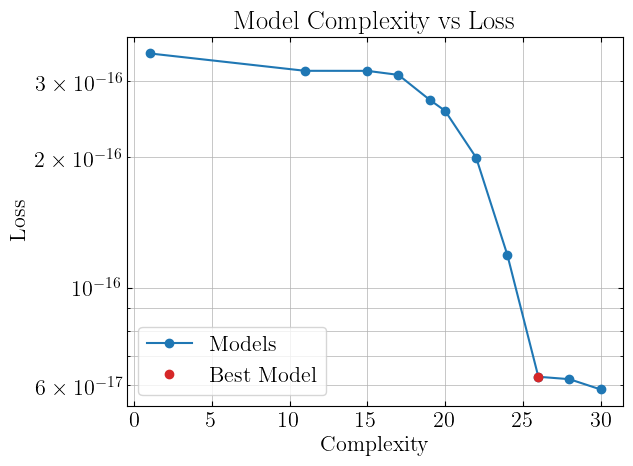

In [54]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.03499738
Equation: 0.7819157

Model 1: Complexity=3, Loss=0.02589574
Equation: sqrt(x2)

Model 2: Complexity=5, Loss=0.023149852
Equation: x2 ^ x2

Model 3: Complexity=7, Loss=0.017885173
Equation: (0.030197676 / (x2 - 0.26137272)) + x2

Model 4: Complexity=9, Loss=0.014170086
Equation: x2 + (x0 * cube(0.20705101 / x2))

Model 5: Complexity=11, Loss=0.00899352
Equation: x2 + (((0.5723021 / x2) ^ x0) * 0.13351294)

Model 6: Complexity=13, Loss=0.0047321
Equation: x2 * ((cube((0.70887774 / x2) + -1.2328088) * x0) + 1.1903067)

Model 7: Complexity=15, Loss=0.0044927807
Equation: ((x0 * (cube((0.6982801 / x2) + -1.1919719) + -0.029409342)) + 1.2232257) * x2

Model 8: Complexity=17, Loss=0.00250697
Equation: (((x0 * cube((0.7247464 / x2) + -1.2636322)) + 1.2751714) * x2) + (x1 * -0.004748755)

Model 9: Complexity=19, Loss=0.0024553735
Equation: ((x0 + x1) * -0.0047558425) + (((cube(-1.2586533 + (0.7251072 / x2)) * x0) + 1.2796978) * x2)

Model 10: Complexity=20

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x1*(-0.0045778425) + x2*(1.6920794**x0*(-1.0555869 + 0.60660833/x2)**3 + 1.2657487)
Loss: 0.0017893242
Best model complexity: 21


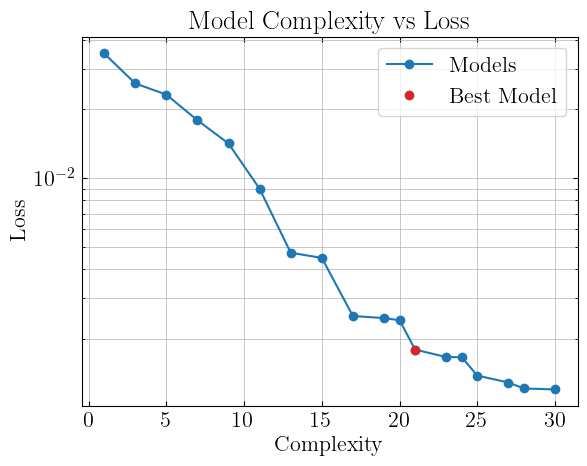

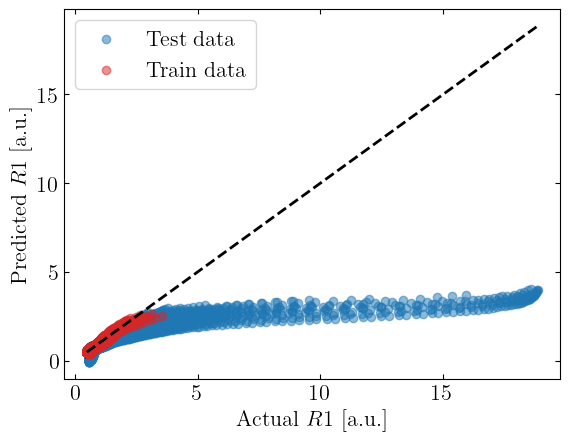

In [55]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=23.61813
Equation: 7.0746255

Model 1: Complexity=3, Loss=7.327996
Equation: 4.4615927 / x2

Model 2: Complexity=5, Loss=2.0575607
Equation: 22.009384 - (x2 * 22.972961)

Model 3: Complexity=7, Loss=2.0395334
Equation: (x2 + -23.312466) * (x2 - 0.9604524)

Model 4: Complexity=9, Loss=1.3417611
Equation: (x2 ^ x2) ^ -7.040266

Model 5: Complexity=11, Loss=1.0068756
Equation: ((x2 ^ x2) ^ -8.623975) * 0.578663

Model 6: Complexity=12, Loss=0.9873885
Equation: (cube(x2 * log(x2)) + -0.004399578) * -251.73225

Model 7: Complexity=13, Loss=0.9867624
Equation: (x2 + ((x2 ^ x2) ^ -9.279591)) * 0.45139548

Model 8: Complexity=14, Loss=0.7981918
Equation: (cube(x2 * log(x2)) + -0.004459074) * (-239.5858 - x1)

Model 9: Complexity=16, Loss=0.7832783
Equation: (cube((x2 * 1.1267928) * log(x2)) + -0.0063850028) * (-163.7962 - x1)

Model 10: Complexity=18, Loss=0.63390946
Equation: ((25.241636 / x0) + (-259.8854 - x1)) * (cube(x2 * log(x2)) + -0.004542367)

Model 11: Com

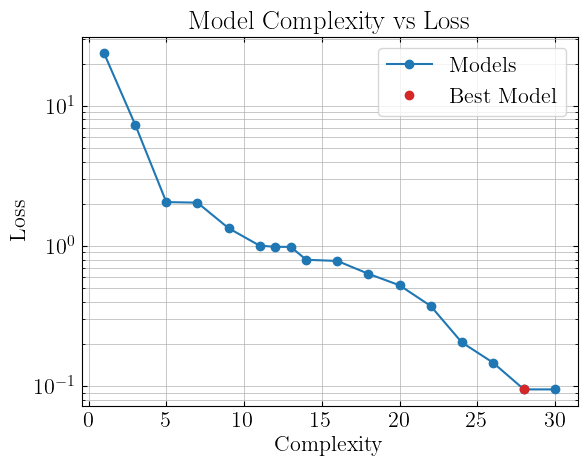

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (2.24133240325586*x2**3*log(x2 + 0.045865916/x0)**3 - 0.008576702)*(-x1 - 153.49162 + (8.714349*x0 - 10.2602361694644)/x2)
Loss: 0.09513705
Best model complexity: 28


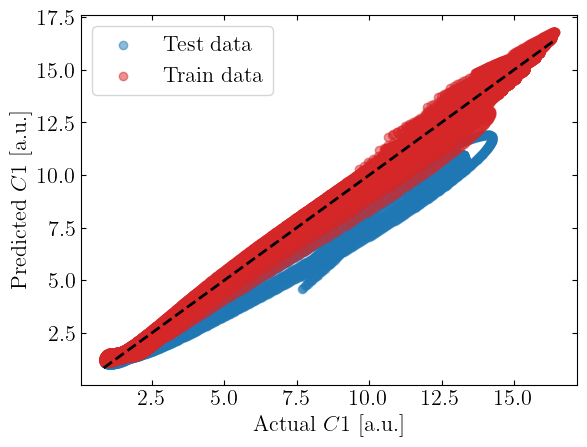

In [56]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.1314518
Equation: 2.6759584

Model 1: Complexity=5, Loss=0.0028731562
Equation: (x1 * 0.03700977) + 2.2414966

Model 2: Complexity=7, Loss=0.00068598107
Equation: (1.0261 ^ x1) + 1.2788414

Model 3: Complexity=9, Loss=0.0005633839
Equation: ((x1 * 0.0006126895) * (x1 + 33.290066)) + 2.2945552

Model 4: Complexity=10, Loss=0.00038031492
Equation: exp((x1 - x2) * 0.026066573) + 1.2956954

Model 5: Complexity=11, Loss=0.00015752757
Equation: ((1.0260698 ^ x1) + 1.3521346) + (x2 * -0.11195314)

Model 6: Complexity=12, Loss=0.00010592693
Equation: exp((x1 - (x2 * 3.306652)) * 0.026793653) + 1.3376379

Model 7: Complexity=13, Loss=7.378018e-06
Equation: ((x1 + 35.8388) * ((x2 * -0.002403689) + (x1 * 0.00061268423))) + 2.3505523

Model 8: Complexity=15, Loss=7.377926e-06
Equation: (((x1 - -0.00016657592) + 35.8388) * ((x2 * -0.002403689) + (x1 * 0.00061268423))) + 2.3505523

Model 9: Complexity=17, Loss=7.22313e-06
Equation: (((x1 + 34.164524) * ((x1 * 0.00061148

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (x1*0.0005971261 + x2*(-0.0023538745))*(x1 - x2/(x1 + 0.18206175) + 37.70814) + 2.3480022
Loss: 4.551622e-06
Best model complexity: 19


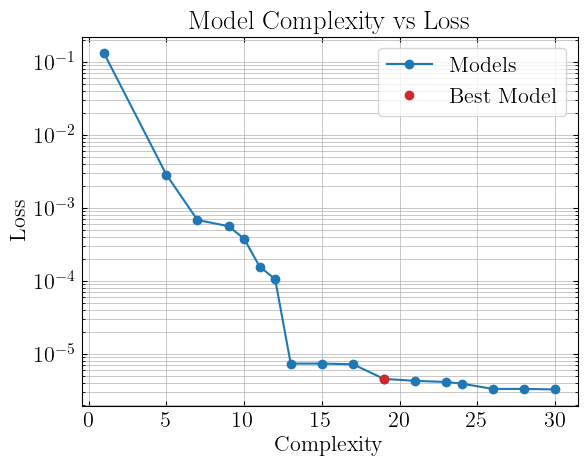

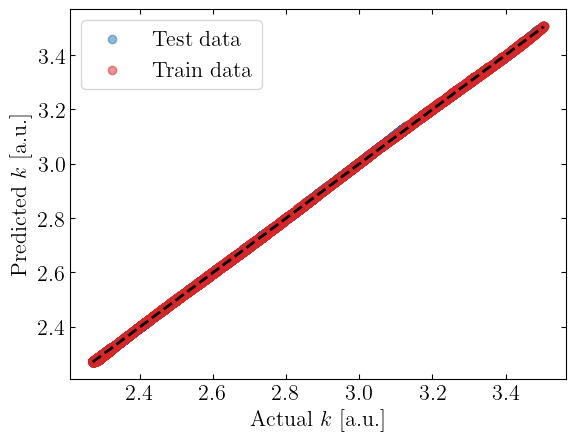

In [57]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.010004441
Equation: 0.16942313

Model 1: Complexity=3, Loss=0.00013210776
Equation: x0 * 0.09885413

Model 2: Complexity=5, Loss=0.000118798656
Equation: x0 / (x2 + 9.470324)

Model 3: Complexity=7, Loss=1.7276212e-05
Equation: x0 / ((x1 * 0.056142766) + 9.470398)

Model 4: Complexity=9, Loss=5.0913595e-06
Equation: x0 / (((x2 * 0.08434303) * x1) + 9.490027)

Model 5: Complexity=11, Loss=2.8602801e-06
Equation: ((0.971224 / ((x2 * x1) + 26.395018)) - -0.06930193) * x0

Model 6: Complexity=13, Loss=2.3650198e-06
Equation: ((0.84949446 / (((x1 + 1.8400074) * x2) + 23.140018)) - -0.071169645) * x0

Model 7: Complexity=15, Loss=1.9241102e-06
Equation: (x0 * ((0.8935005 / (((x2 + x1) * x2) + 24.595442)) - -0.07103572)) + -0.0013599251

Model 8: Complexity=17, Loss=1.6554585e-06
Equation: (0.062961355 - (-0.4020644 / (((((0.28724566 + x2) * x1) * 0.19180392) + x2) + 8.692631))) * x0

Model 9: Complexity=18, Loss=1.599424e-06
Equation: (0.060035534 - (-0.4219979 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x0*(0.06600331 - (-1)*0.3963741/(x1*(exp(x2) + (x2 - 1*0.71809757)/x0)*0.10570667 + x2 + 9.080024)) - 0.0016846734
Loss: 7.711709e-07
Best model complexity: 26


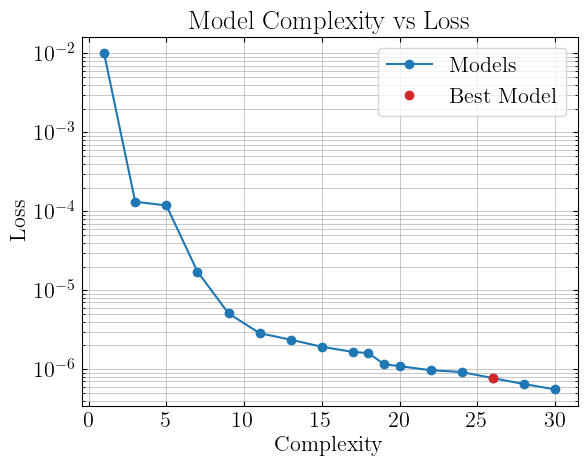

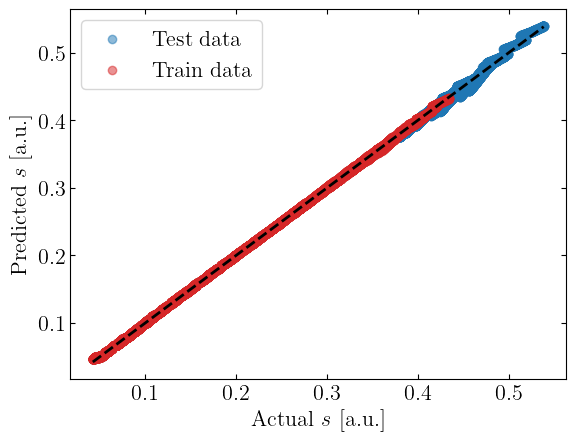

In [58]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s, s = True)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [59]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [60]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

<lambdifygenerated-41>:2: RuntimeWarning: overflow encountered in exp
  return 0.7/exp(exp(exp((x0 - 0.021295063*x1 + x2/(-0.10081373))/0.6895431)))**(-2.9813787e-8)
<lambdifygenerated-41>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.7/exp(exp(exp((x0 - 0.021295063*x1 + x2/(-0.10081373))/0.6895431)))**(-2.9813787e-8)


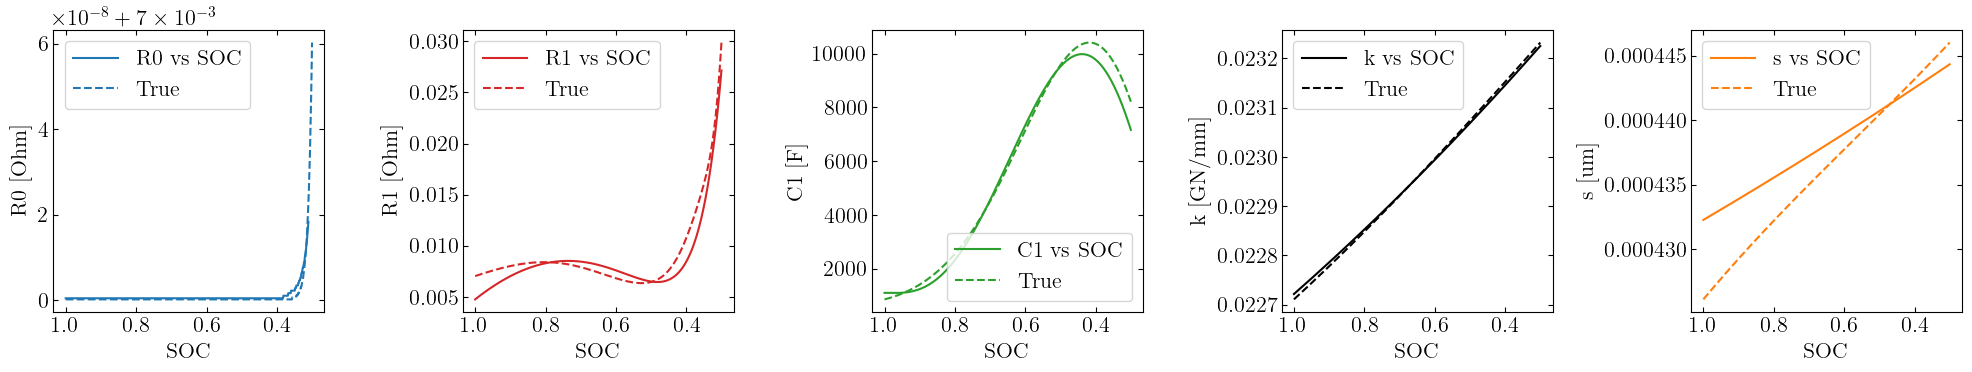

In [61]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        if var == 's':
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
            Y_true = traj['sdot']
        else:
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
            Y_true = traj[var]
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 1, test = True)
plot_soc(MODEL_DICT, traj)

In [62]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [63]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')